In [1]:
import dataclasses
import logging
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import seaborn as sns
from mne.viz import plot_topomap

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:  # noqa: B007
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from sklearn.decomposition import PCA, FastICA  # noqa: E402

from scripts.analysis_common import (  # noqa: E402
    FREQUENCY_BANDS,
    _WAVELET_BAND_FREQ_RESOLUTION_HZ,
    _wavelet_transform,
    analyzers_to_datasets,
    load_analyzers,
)
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
%matplotlib inline


# Temporal ICA / PCA on Wavelet Power

**Approach 3** — concatenate *subject × channel* into observations,
keep *frequency × time* as features.

```
(n_subjects, n_channels, n_freqs, n_times)
  → reshape →  (n_subjects × n_channels,  n_freqs × n_times)
```

Each observation is a single *electrode from a single subject*, described
by its full frequency × time power surface.  ICA discovers **temporal-spectral
components** — recurring frequency × time patterns shared across subjects
and channels.  The focus is on **time**: components that are active in the
same temporal intervals across subjects indicate stimulus-driven processing.

Each component has loadings on every `(subject, channel)` pair, which
can be decomposed into:

| Loading dimension | Interpretation |
|-------------------|----------------|
| Subject loadings  | Which participants contribute most to the component |
| Channel loadings  | Spatial topography (scalp map) of the component |

And the component itself is a frequency × time map showing:

| Component dimension | Interpretation |
|---------------------|----------------|
| Frequency × time map | When and at what frequency the component is active |

**Analyses:**

1. PCA scree plot (variance explained)
2. ICA frequency × time component maps
3. ICA topographic maps — mean loading across subjects
4. ICA topographic maps — variance of loadings across subjects
5. Per-subject ICA channel loadings
6. ICA component time courses (frequency-marginalized)
7. ICA component spectral profiles (time-marginalized)
8. Inter-subject correlation of ICA component activations
9. Band-resolved ICA component energy
10. Cross-component correlation matrix


## Configuration


In [2]:
# ── Experiment configuration ─────────────────────────────────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL]  # single type for fast exploration
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]
PROCESS_AND_SAVE_DATA = False  # set True to re-process raw files

# ── Wavelet settings ───────────────────────────────────────────────────────────────
REPRESENTATION = "power"
WAVELET_FREQ_MIN = min(lo for lo, _ in FREQUENCY_BANDS.values())
WAVELET_FREQ_MAX = max(hi for _, hi in FREQUENCY_BANDS.values())
WAVELET_N_FREQS = max(
    2,
    int(
        round(
            (WAVELET_FREQ_MAX - WAVELET_FREQ_MIN)
            / _WAVELET_BAND_FREQ_RESOLUTION_HZ
        )
    )
    + 1,
)
FREQS = np.linspace(WAVELET_FREQ_MIN, WAVELET_FREQ_MAX, WAVELET_N_FREQS)

KEEP_FREQUENCY_DIM = True
RESHAPE_FREQUENCY_DIM = True  # -> (n_subjects, n_channels, n_freqs, n_times)

# ── Reuse / compute ────────────────────────────────────────────────────────────────
REUSE_WAVELETS = True  # load from cache; set False to compute + save

# ── Subsets ──────────────────────────────────────────────────────────────────────
N_SUBJECTS_SUBSET: int | None = 5
N_CHANNELS_SUBSET: int | None = 32
N_TIMES_SUBSET: int | None = 10000

# ── Decomposition settings ──────────────────────────────────────────────────────────
N_COMPONENTS_PCA = 20  # number of PCA components to retain
N_COMPONENTS_ICA = 10  # number of ICA components to extract
ICA_RANDOM_STATE = 42

# ── Storage directory ───────────────────────────────────────────────────────────────
WAVELET_DIR: Path = (
    ProjectPaths.NOTEBOOKS_DIR / "04-wavelet-ica-analysis" / "wavelet_cache"
)

# ── Plot saving ──────────────────────────────────────────────────────────────────
SAVE_PLOTS = True
PLOTS_DIR = (
    ProjectPaths.NOTEBOOKS_DIR
    / "04-wavelet-ica-analysis"
    / "plots"
    / "temporal"
)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wavelet base directory : {WAVELET_DIR}")
print(
    f"Frequencies            : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz"
    f" ({len(FREQS)} steps)"
)
print(f"PCA components         : {N_COMPONENTS_PCA}")
print(f"ICA components         : {N_COMPONENTS_ICA}")


Wavelet base directory : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache
Frequencies            : 1.0–70.0 Hz (70 steps)
PCA components         : 20
ICA components         : 10


## Data Loading


In [3]:
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    PROCESS_AND_SAVE_DATA,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)

if N_SUBJECTS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:N_SUBJECTS_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_SUBJECTS_SUBSET} individuals.")

if N_CHANNELS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(
            ad, data=ad.data[:, :N_CHANNELS_SUBSET, :]
        )
        for label, ad in datasets.items()
    }
    print(f"Using first {N_CHANNELS_SUBSET} channels.")

if N_TIMES_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(
            ad, data=ad.data[:, :, :N_TIMES_SUBSET]
        )
        for label, ad in datasets.items()
    }
    print(f"Using first {N_TIMES_SUBSET} time samples.")

print("Loaded datasets:", list(datasets.keys()))
for label, ad in datasets.items():
    print(
        f"  {label}: {ad.n_items} subjects, "
        f"{ad.n_features} channels, {ad.n_samples} samples"
    )


INFO src.analysis.summary.EEGSummarizedAnalyzer: Data loaded from /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/concatenated/Placebo_CLASSIC.npy  (shape=(15, 195, 91392))


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(
INFO scripts.analysis_common: [Placebo_CLASSIC] Loaded data shape: (15, 195, 91392)
INFO scripts.analysis_common: [Placebo_CLASSIC] AnalysisData('Placebo_CLASSIC', time_domain, 15 items × 195 features × 91392 samples, sfreq=250.0)


Using first 5 individuals.
Using first 32 channels.
Using first 10000 time samples.
Loaded datasets: ['Placebo_CLASSIC']
  Placebo_CLASSIC: 5 subjects, 32 channels, 10000 samples


## Load or Compute Wavelet Transforms

Stored in `WAVELET_DIR/broadband/`.


In [4]:
broadband_datasets = _wavelet_transform(
    datasets=datasets,
    freqs=FREQS,
    representation=REPRESENTATION,
    keep_frequency_dim=KEEP_FREQUENCY_DIM,
    reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
    wavelet_dir=WAVELET_DIR / "broadband",
    reuse_wavelets=REUSE_WAVELETS,
)
for label, ad in broadband_datasets.items():
    source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
    print(f"[broadband] {label}: shape={ad.data.shape}  source={source}")


[broadband] Placebo_CLASSIC: shape=(5, 32, 70, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache/broadband/Placebo_CLASSIC__wavelet_power__1.000_70.000_70__freqdim1.npz


## Dataset Selection

Change `LABEL` to switch between music types.


In [5]:
LABEL = list(broadband_datasets.keys())[0]

bb_ad = broadband_datasets[LABEL]
bb_data = bb_ad.data  # (n_subjects, n_channels, n_freqs, n_times)
sfreq = bb_ad.sfreq

n_subjects, n_channels, n_freqs, n_times = bb_data.shape
time = np.arange(n_times) / sfreq

# Prepare MNE Info for topographic maps
topo_info = analyzers[LABEL].info
topo_info = mne.pick_info(topo_info, mne.pick_types(topo_info, eeg=True))
if n_channels < len(topo_info.ch_names):
    topo_info = mne.pick_info(topo_info, list(range(n_channels)))

print(f"Dataset    : {LABEL}")
print(
    f"Shape      : {bb_data.shape}"
    f"  (subjects × channels × freqs × times)"
)
print(f"Duration   : {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print(f"Freq range : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({n_freqs} steps)")


Dataset    : Placebo_CLASSIC
Shape      : (5, 32, 70, 10000)  (subjects × channels × freqs × times)
Duration   : 40.0 s  @  250.0 Hz
Freq range : 1.0–70.0 Hz (70 steps)


## Temporal Reshape

Flatten `(n_subjects, n_channels)` into the observation axis and
`(n_freqs, n_times)` into the feature axis.

```
X_temporal:  (n_subjects × n_channels,  n_freqs × n_times)
```

Each row is one electrode from one subject, described by its full
frequency × time power surface.  PCA/ICA discover recurring
temporal-spectral patterns shared across subjects and channels.

The key insight: components that activate in the **same time intervals**
across subjects indicate stimulus-driven neural processing.


In [6]:
# Reshape 4-D → 2-D:  (n_subjects * n_channels,  n_freqs * n_times)
X_temporal = bb_data.reshape(
    n_subjects * n_channels, n_freqs * n_times
)
print(f"Temporal matrix shape: {X_temporal.shape}")
print(f"  Rows = {n_subjects} subjects × {n_channels} channels")
print(f"  Cols = {n_freqs} frequencies × {n_times} time points")

# Z-score each row (observation) across features
row_mean = X_temporal.mean(axis=1, keepdims=True)
row_std = X_temporal.std(axis=1, keepdims=True) + 1e-10
X_temporal_z = (X_temporal - row_mean) / row_std
print("Z-scored temporal matrix ready.")


Temporal matrix shape: (160, 700000)
  Rows = 5 subjects × 32 channels
  Cols = 70 frequencies × 10000 time points
Z-scored temporal matrix ready.


---
## 1 — PCA Scree Plot (Variance Explained)

How many temporal-spectral components capture meaningful variance?
The scree plot shows the intrinsic dimensionality of the
frequency × time space across all subjects and channels.


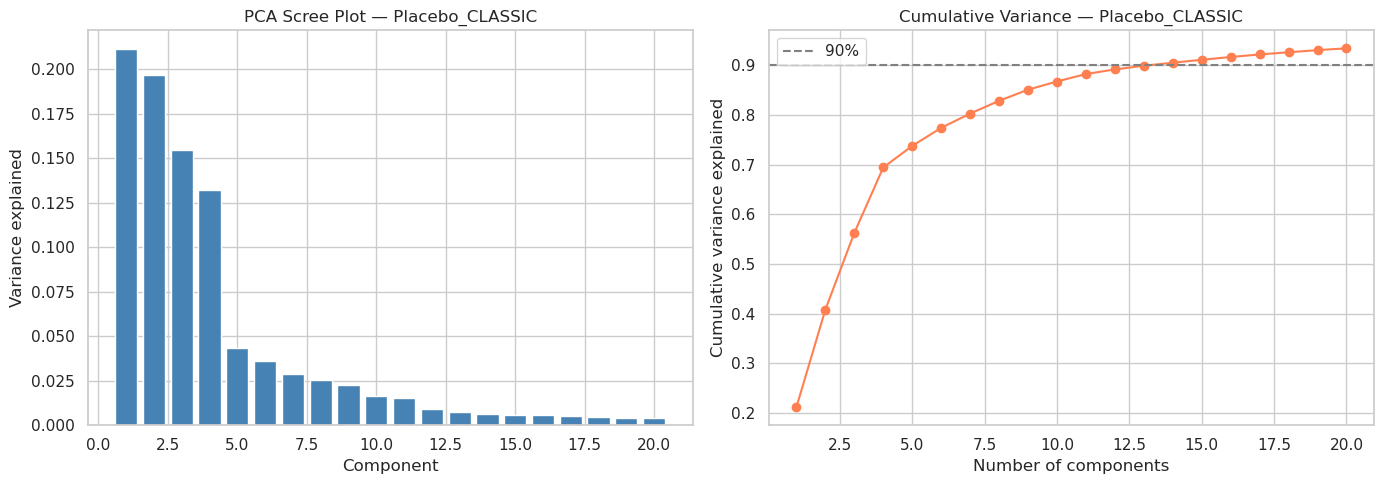

Top 20 components explain 93.4% of total variance.


In [7]:
pca = PCA(n_components=N_COMPONENTS_PCA, random_state=ICA_RANDOM_STATE)
pca.fit(X_temporal_z)  # (n_obs, n_features)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(explained) + 1), explained, color="steelblue")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance explained")
axes[0].set_title(f"PCA Scree Plot — {LABEL}")

axes[1].plot(
    range(1, len(cumulative) + 1), cumulative, "o-", color="coral"
)
axes[1].axhline(0.9, ls="--", color="gray", label="90%")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained")
axes[1].set_title(f"Cumulative Variance — {LABEL}")
axes[1].legend()

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"Top {N_COMPONENTS_PCA} components explain "
    f"{cumulative[-1] * 100:.1f}% of total variance."
)


---
## Fit ICA

Apply FastICA to the z-scored temporal matrix.  Each ICA component
is a frequency × time pattern; each observation’s (subject, channel)
loading tells how strongly that electrode activates the pattern.


In [8]:
ica = FastICA(
    n_components=N_COMPONENTS_ICA,
    random_state=ICA_RANDOM_STATE,
    max_iter=500,
    whiten="unit-variance",
)
ica_scores = ica.fit_transform(X_temporal_z)  # (S*C, K_ica)

# ica.mixing_: (n_features, K_ica) = (F*T, K_ica)
# ica.components_: (K_ica, n_features) = (K_ica, F*T)
# ica_scores: (S*C, K_ica) — per-(subject, channel) activation

# Reshape scores to (n_subjects, n_channels, K_ica)
ica_scores_3d = ica_scores.reshape(n_subjects, n_channels, N_COMPONENTS_ICA)

# Reshape component vectors to (K_ica, n_freqs, n_times)
ica_components_ft = ica.components_.reshape(
    N_COMPONENTS_ICA, n_freqs, n_times
)

print(f"ICA scores shape     : {ica_scores.shape}  (S*C, K)")
print(f"ICA scores 3D shape  : {ica_scores_3d.shape}  (S, C, K)")
print(f"ICA components shape : {ica_components_ft.shape}  (K, F, T)")


ICA scores shape     : (160, 10)  (S*C, K)
ICA scores 3D shape  : (5, 32, 10)  (S, C, K)
ICA components shape : (10, 70, 10000)  (K, F, T)


---
## 2 — ICA Frequency × Time Component Maps

Each ICA component is a vector of length `n_freqs × n_times`.
Reshape to `(n_freqs, n_times)` and display as a heatmap.
This is the **temporal-spectral fingerprint** of the component —
bright regions show when and at what frequency the component is active.


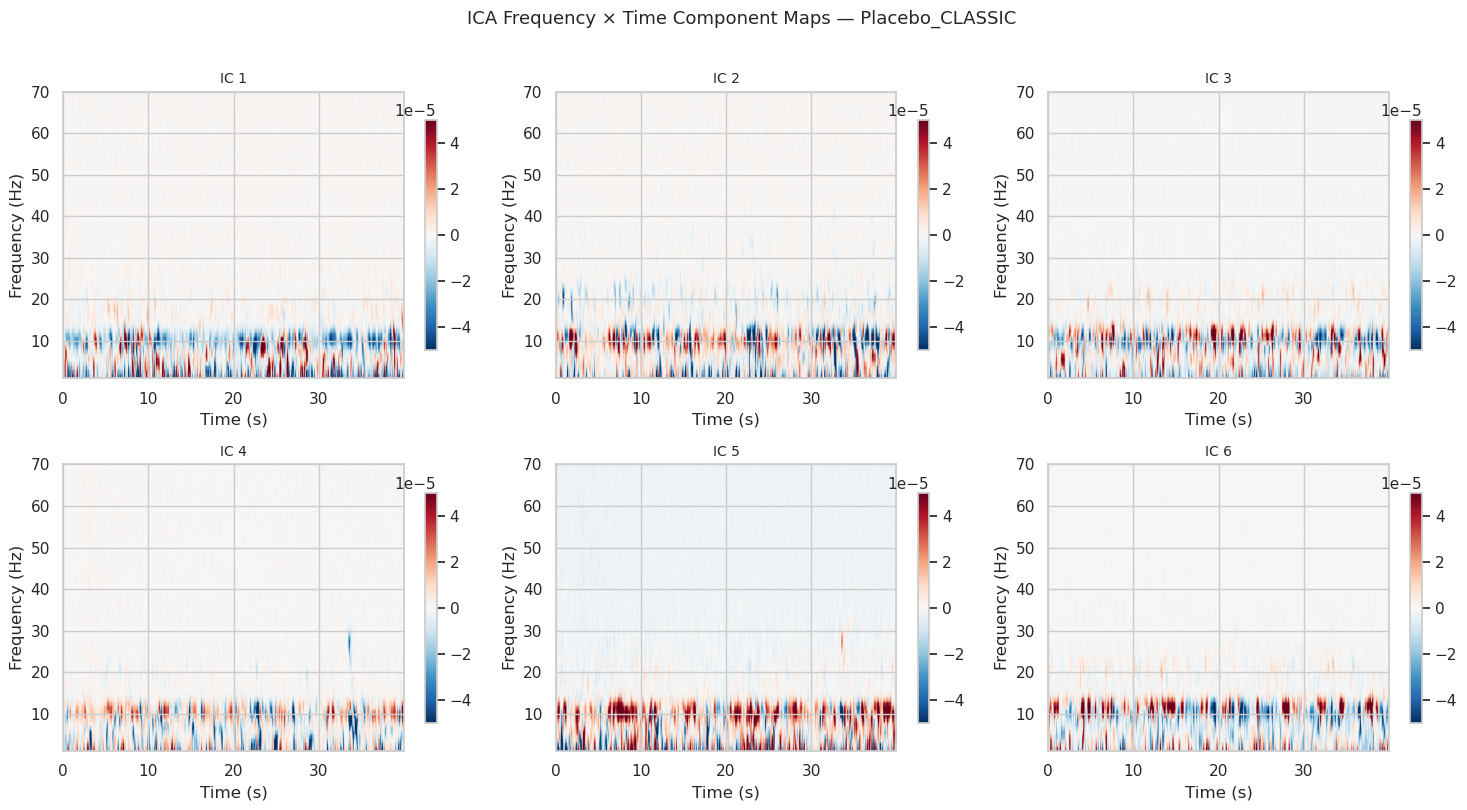

In [9]:
n_show = min(6, N_COMPONENTS_ICA)
n_cols = min(3, n_show)
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows)
)
axes = np.atleast_2d(axes).ravel()

_vlim = np.percentile(np.abs(ica_components_ft[:n_show]), 99)
for i in range(n_show):
    comp_ft = ica_components_ft[i]  # (n_freqs, n_times)
    im = axes[i].imshow(
        comp_ft,
        aspect="auto",
        origin="lower",
        extent=[time[0], time[-1], FREQS[0], FREQS[-1]],
        cmap="RdBu_r",
        vmin=-_vlim,
        vmax=_vlim,
    )
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Frequency (Hz)")
    axes[i].set_title(f"IC {i + 1}", fontsize=10)
    plt.colorbar(im, ax=axes[i], shrink=0.8)

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"ICA Frequency × Time Component Maps — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_freq_time_maps.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 3 — ICA Topographic Maps — Mean Loading Across Subjects

For each ICA component, the loading on every `(subject, channel)` pair
is available in `ica_scores_3d` of shape `(n_subjects, n_channels, K)`.

Average over subjects to get the **mean channel loading** per component,
then plot as a scalp topography.  This shows where on the scalp
each temporal-spectral pattern is most active on average.


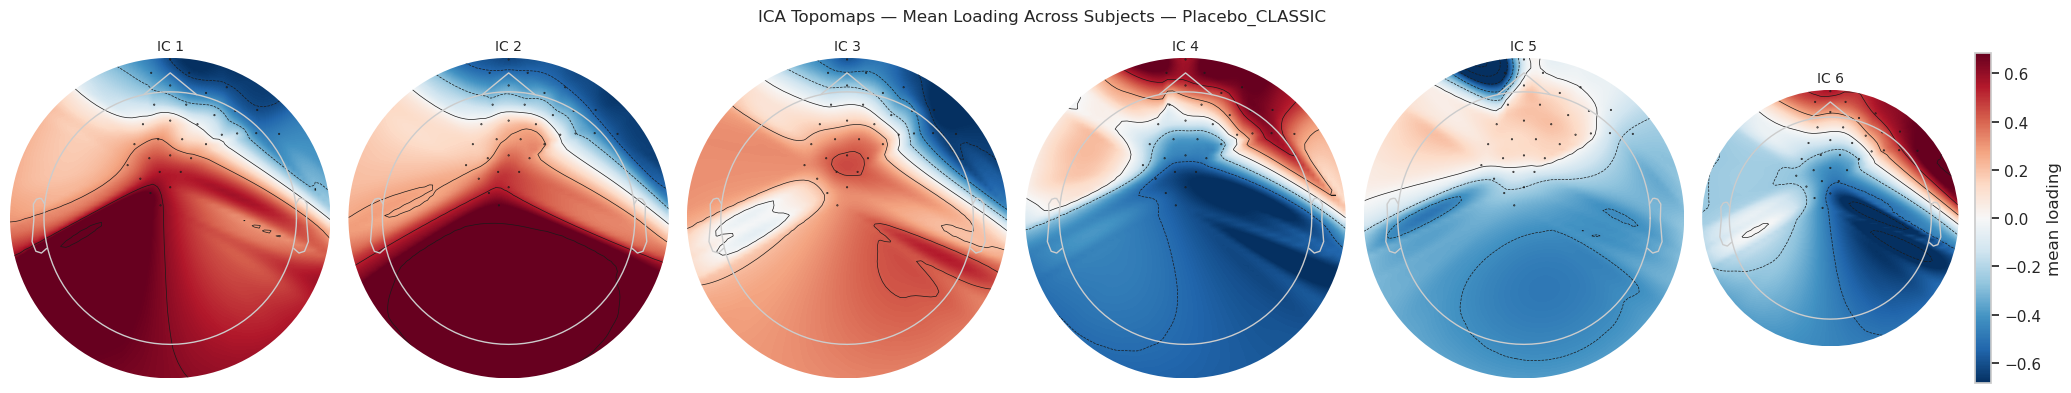

In [11]:
# Mean loading across subjects: (n_channels, K)
ica_channel_mean = ica_scores_3d.mean(axis=0)  # (C, K)

n_show = min(6, N_COMPONENTS_ICA)
_vlim_mean = np.percentile(np.abs(ica_channel_mean[:, :n_show]), 99)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im, _ = plot_topomap(
        ica_channel_mean[:, i],
        topo_info,
        axes=ax,
        show=False,
        cmap="RdBu_r",
        # vmin=-_vlim_mean,
        # vmax=_vlim_mean,
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"ICA Topomaps — Mean Loading Across Subjects — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="mean loading")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_topomap_mean.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 4 — ICA Topographic Maps — Variance of Loadings Across Subjects

Compute the **variance** of each channel’s loading across subjects.
High variance means the component has very different strength at that
electrode across individuals — potentially marking idiosyncratic
contributions.  Low variance means consistent activation.


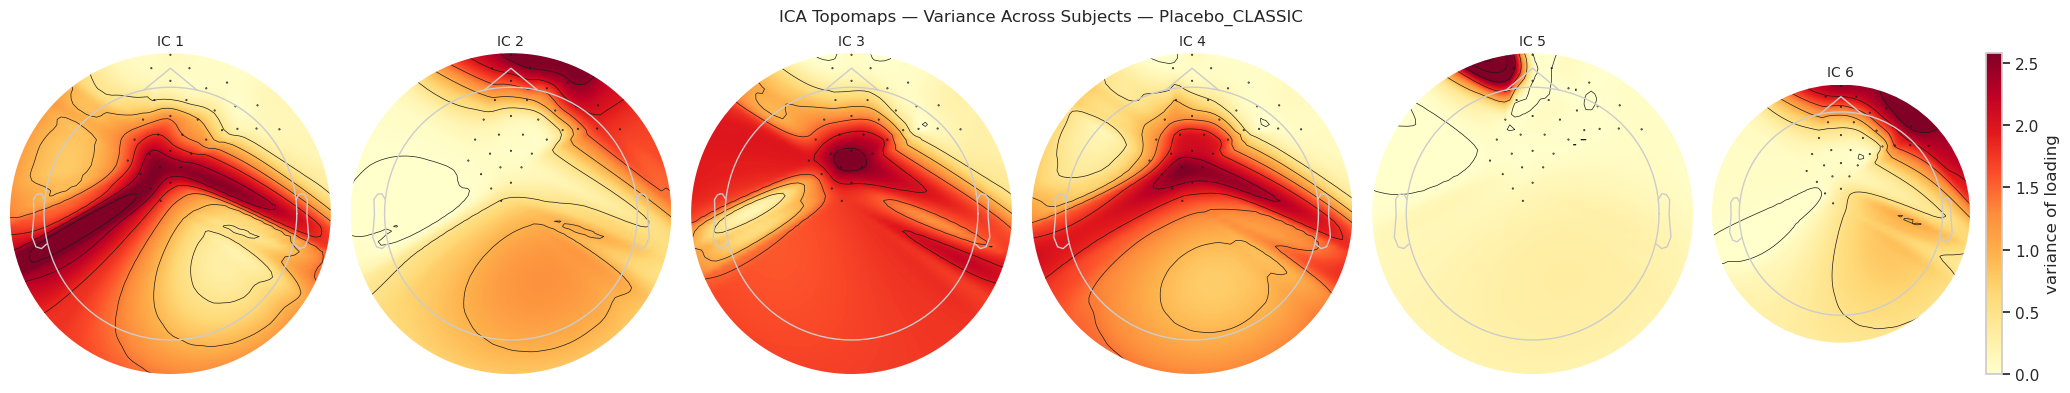

In [13]:
# Variance of loading across subjects: (n_channels, K)
ica_channel_var = ica_scores_3d.var(axis=0)  # (C, K)

n_show = min(6, N_COMPONENTS_ICA)
_vmax_var = np.percentile(ica_channel_var[:, :n_show], 99)
fig, axes = plt.subplots(1, n_show, figsize=(3.5 * n_show, 4))
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    im, _ = plot_topomap(
        ica_channel_var[:, i],
        topo_info,
        axes=ax,
        show=False,
        cmap="YlOrRd",
        # vmin=0,
        # vmax=_vmax_var,
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"ICA Topomaps — Variance Across Subjects — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="variance of loading")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_topomap_variance.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 5 — Per-Subject ICA Channel Loadings

For each ICA component, show the channel loading as a separate
topomap for each subject.  This reveals whether the spatial
distribution is consistent or subject-specific.


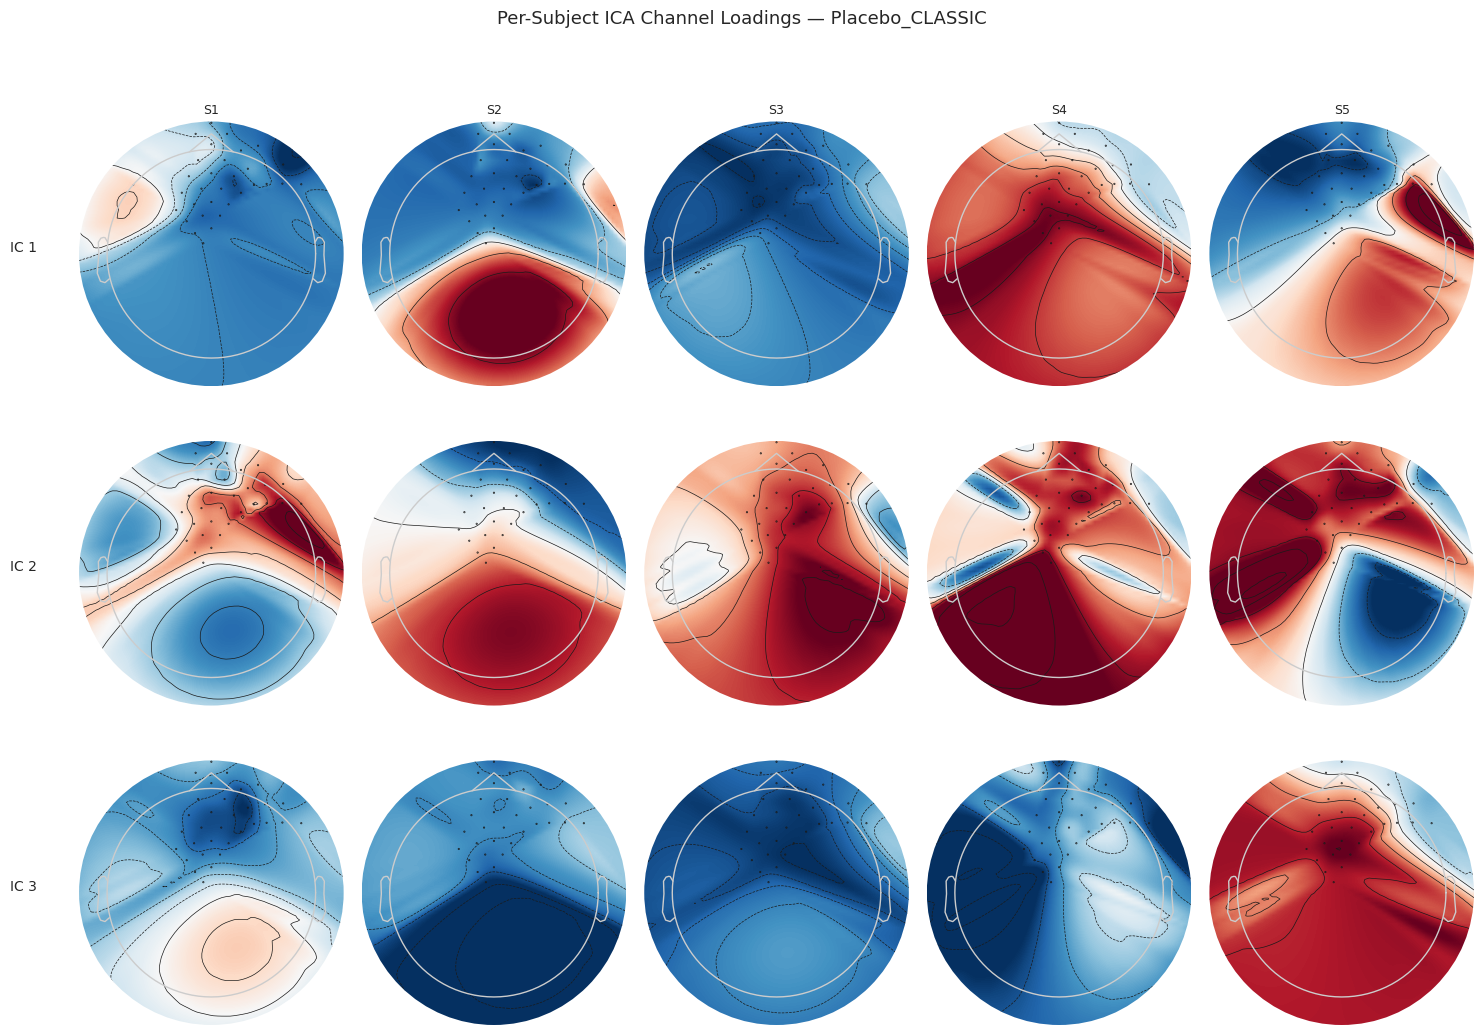

In [15]:
n_show_comp = min(3, N_COMPONENTS_ICA)
fig, axes = plt.subplots(
    n_show_comp,
    n_subjects,
    figsize=(3 * n_subjects, 3.5 * n_show_comp),
)
if n_show_comp == 1:
    axes = axes[np.newaxis, :]

_vlim_subj = np.percentile(np.abs(ica_scores_3d[:, :, :n_show_comp]), 99)
for k in range(n_show_comp):
    for s in range(n_subjects):
        im, _ = plot_topomap(
            ica_scores_3d[s, :, k],
            topo_info,
            axes=axes[k, s],
            show=False,
            cmap="RdBu_r",
            # vmin=-_vlim_subj,
            # vmax=_vlim_subj,
        )
        if k == 0:
            axes[k, s].set_title(f"S{s + 1}", fontsize=9)
    axes[k, 0].set_ylabel(
        f"IC {k + 1}", fontsize=10, rotation=0, labelpad=40
    )

fig.suptitle(
    f"Per-Subject ICA Channel Loadings — {LABEL}",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_per_subject_topomaps.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 6 — ICA Component Time Courses (Frequency-Marginalized)

Average each ICA component’s frequency × time map over the frequency
axis to get a **temporal activation profile** `(n_times,)`.  This
reveals *when* the component is active.

Components whose time courses peak at the same moments across the
group are candidates for stimulus-driven processing.


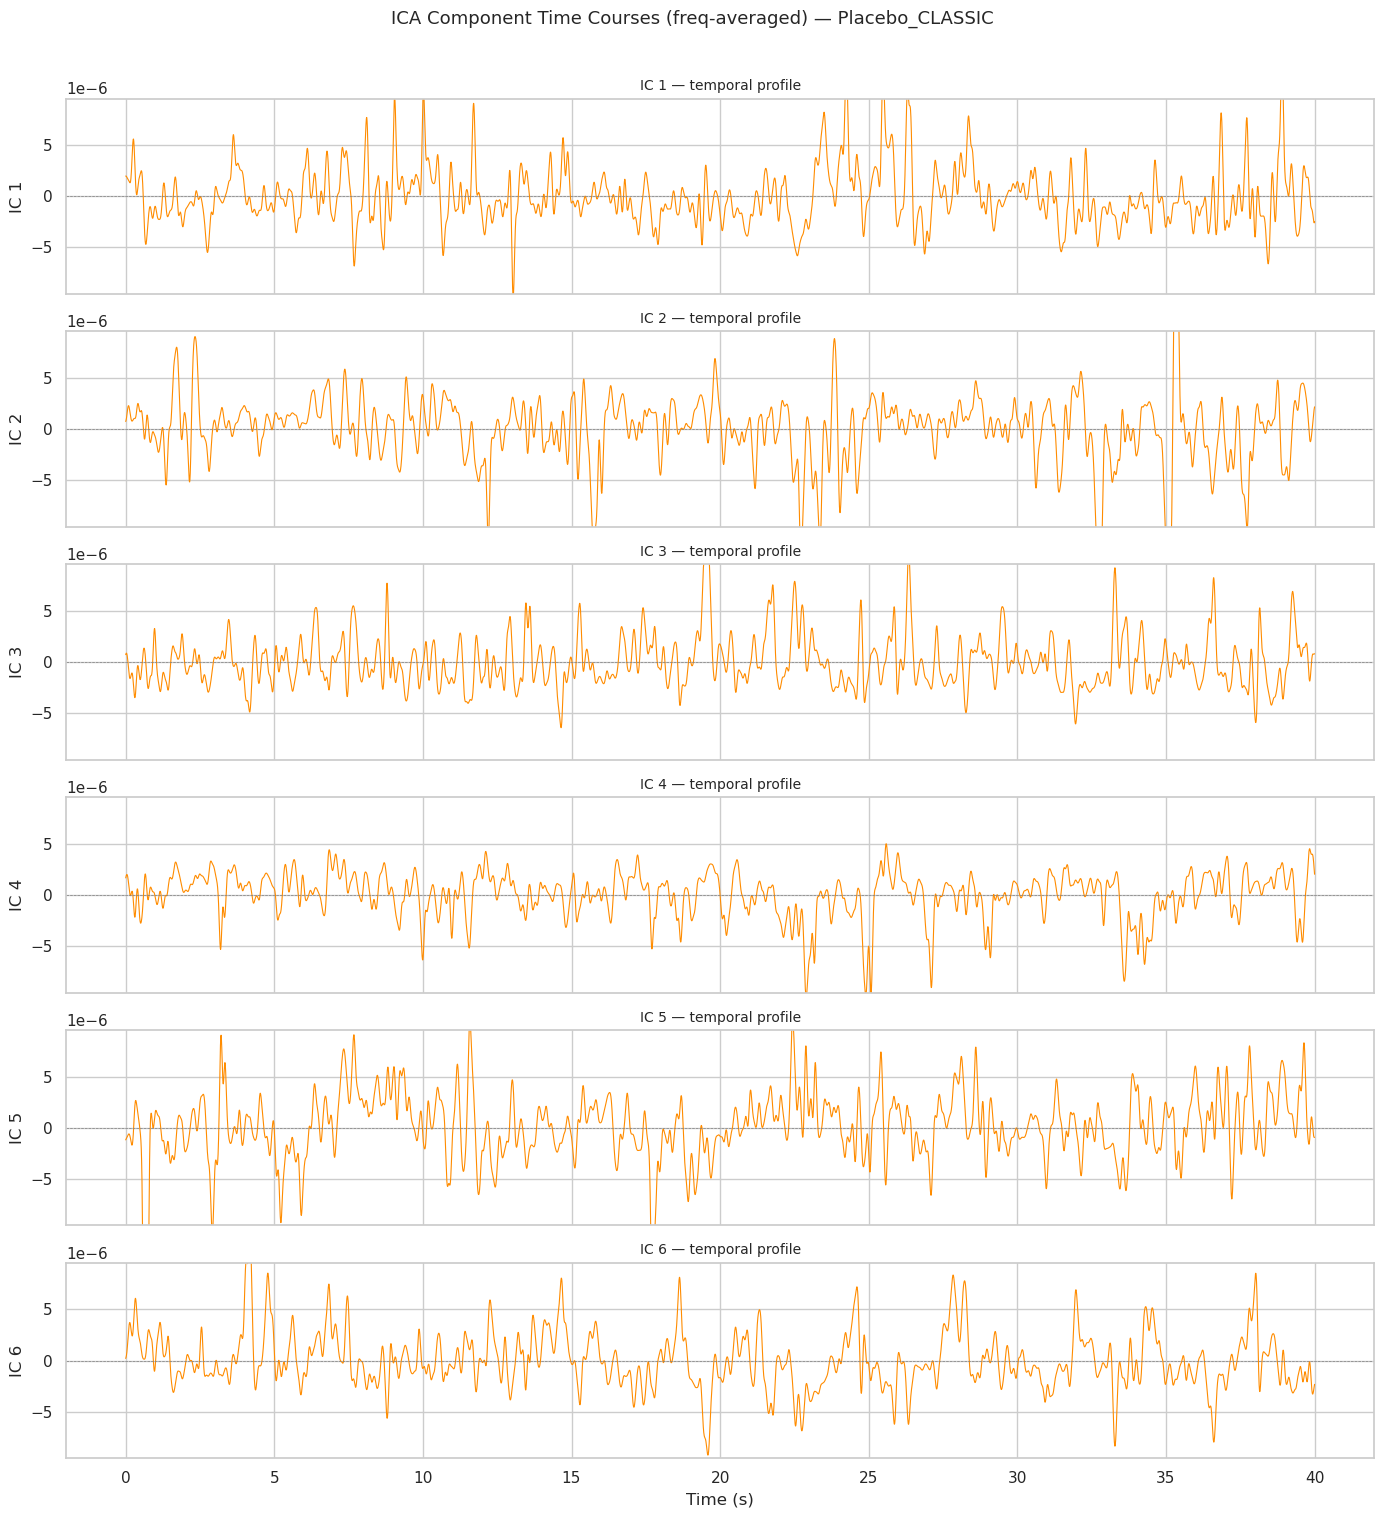

In [16]:
# Marginalize over frequency → (K, n_times)
ica_time_profiles = ica_components_ft.mean(axis=1)  # (K, T)

n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(
    n_show, 1, figsize=(14, 2.5 * n_show), sharex=True
)
if n_show == 1:
    axes = [axes]

_ylim_tc = np.percentile(np.abs(ica_time_profiles[:n_show]), 99)
for i, ax in enumerate(axes):
    ax.plot(time, ica_time_profiles[i], lw=0.8, color="darkorange")
    ax.axhline(0, ls="--", color="gray", lw=0.5)
    ax.set_ylim(-_ylim_tc, _ylim_tc)
    ax.set_ylabel(f"IC {i + 1}")
    ax.set_title(f"IC {i + 1} — temporal profile", fontsize=10)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"ICA Component Time Courses (freq-averaged) — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_timecourses.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 7 — ICA Component Spectral Profiles (Time-Marginalized)

Average each ICA component’s frequency × time map over the time axis
to get a **spectral profile** `(n_freqs,)`.  This shows which
frequency bands dominate each component.


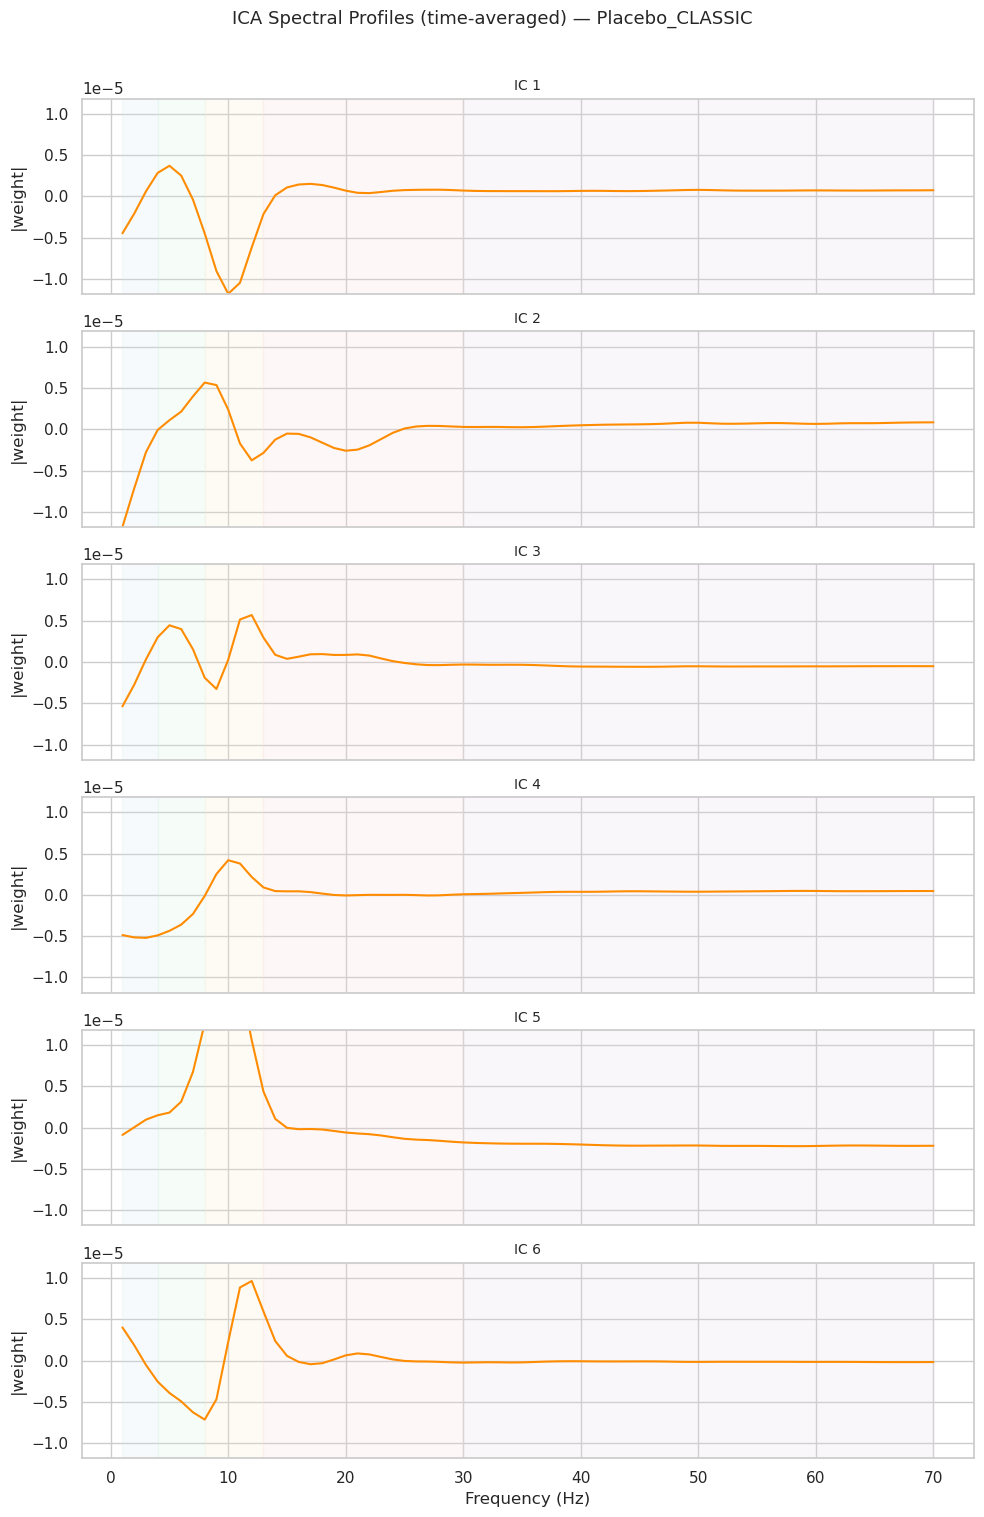

In [17]:
# Marginalize over time → (K, n_freqs)
ica_freq_profiles = ica_components_ft.mean(axis=2)  # (K, F)

band_colors = {
    "delta": "#d4e6f1",
    "theta": "#d5f5e3",
    "alpha": "#fdebd0",
    "beta": "#fadbd8",
    "gamma": "#e8daef",
}

n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(
    n_show, 1, figsize=(10, 2.5 * n_show), sharex=True
)
if n_show == 1:
    axes = [axes]

_ylim_spec = np.percentile(np.abs(ica_freq_profiles[:n_show]), 99)
for i, ax in enumerate(axes):
    ax.plot(FREQS, ica_freq_profiles[i], lw=1.5, color="darkorange")
    ax.set_ylim(-_ylim_spec, _ylim_spec)
    for band, (lo, hi) in FREQUENCY_BANDS.items():
        ax.axvspan(
            lo, hi, alpha=0.2, color=band_colors.get(band, "grey")
        )
    ax.set_ylabel("|weight|")
    ax.set_title(f"IC {i + 1}", fontsize=10)

axes[-1].set_xlabel("Frequency (Hz)")
fig.suptitle(
    f"ICA Spectral Profiles (time-averaged) — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_spectral_profiles.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 8 — Inter-Subject Correlation of ICA Component Activations

For each ICA component, each subject has a channel-loading vector
of length `n_channels`.  Compute the Pearson correlation of these
loading vectors between every pair of subjects.

High inter-subject correlation means the spatial distribution of the
component is consistent across individuals — a hallmark of
stimulus-driven processing.


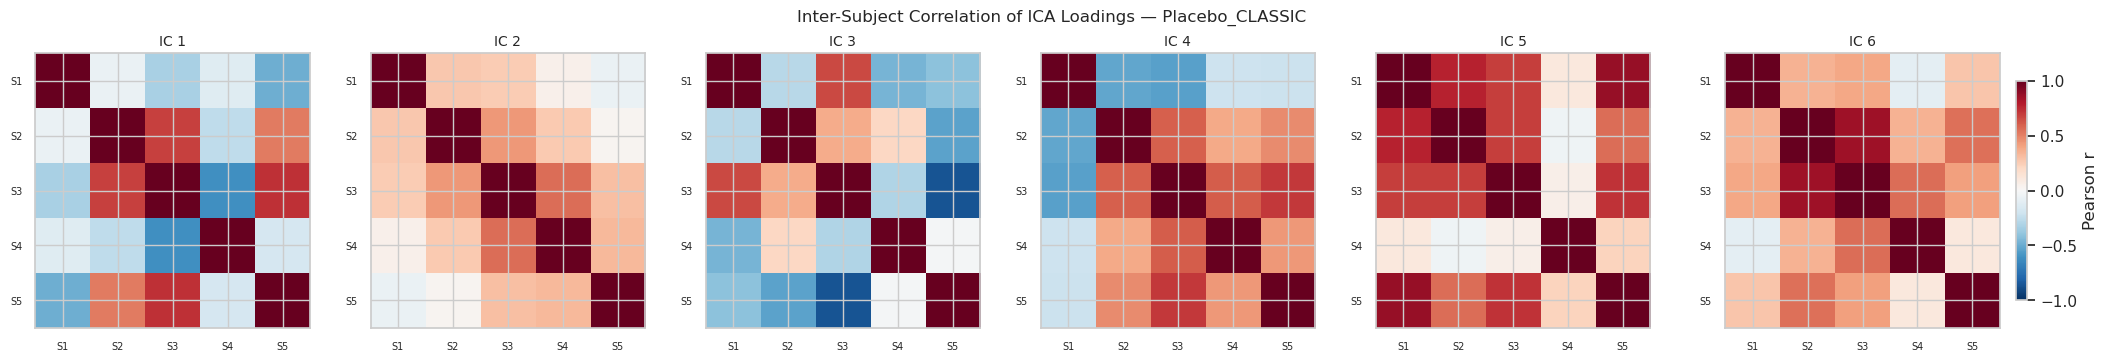

In [18]:
n_show = min(6, N_COMPONENTS_ICA)
fig, axes = plt.subplots(
    1, n_show, figsize=(3.5 * n_show, 3.5), constrained_layout=True
)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    # ica_scores_3d[:, :, i] has shape (n_subjects, n_channels)
    corr_mat = np.corrcoef(ica_scores_3d[:, :, i])  # (S, S)
    im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(n_subjects))
    ax.set_yticks(range(n_subjects))
    ax.set_xticklabels(
        [f"S{s + 1}" for s in range(n_subjects)], fontsize=7
    )
    ax.set_yticklabels(
        [f"S{s + 1}" for s in range(n_subjects)], fontsize=7
    )
    ax.set_title(f"IC {i + 1}", fontsize=10)

fig.suptitle(
    f"Inter-Subject Correlation of ICA Loadings — {LABEL}",
    fontsize=12,
)
plt.colorbar(im, ax=axes[-1], label="Pearson r", shrink=0.8)
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_intersubject_correlation.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 9 — Band-Resolved ICA Component Energy

For each ICA component, aggregate the squared weights within each
canonical frequency band (delta, theta, alpha, beta, gamma) to
quantify how much energy from each band contributes.


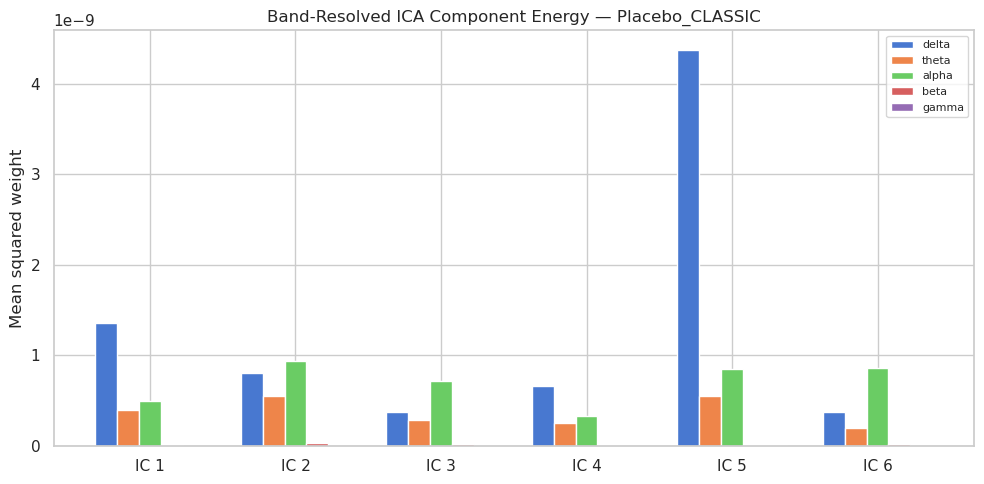

In [19]:
band_energy = {}  # band -> (K,)
for band, (lo, hi) in FREQUENCY_BANDS.items():
    band_mask = (FREQS >= lo) & (FREQS <= hi)
    # Mean squared weight over band freqs and all times
    band_energy[band] = (
        ica_components_ft[:, band_mask, :] ** 2
    ).mean(axis=(1, 2))

bands_list = list(FREQUENCY_BANDS.keys())
n_show = min(6, N_COMPONENTS_ICA)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n_show)
width = 0.15
for j, band in enumerate(bands_list):
    ax.bar(
        x + j * width,
        band_energy[band][:n_show],
        width,
        label=band,
    )

ax.set_xticks(x + width * (len(bands_list) - 1) / 2)
ax.set_xticklabels([f"IC {i + 1}" for i in range(n_show)])
ax.set_ylabel("Mean squared weight")
ax.set_title(f"Band-Resolved ICA Component Energy — {LABEL}")
ax.legend(fontsize=8)

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_band_energy.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## 10 — Cross-Component Correlation Matrix

Compute the Pearson correlation between all pairs of ICA component
time courses (frequency-marginalized).  ICA components should be
approximately independent; off-diagonal values indicate residual
structure.


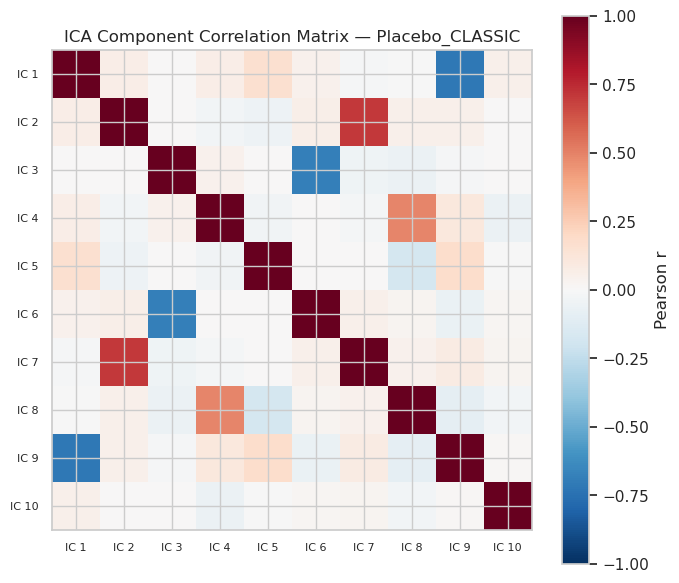

In [20]:
ica_tc_corr = np.corrcoef(ica_time_profiles)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    ica_tc_corr, vmin=-1, vmax=1, cmap="RdBu_r"
)
ax.set_xticks(range(N_COMPONENTS_ICA))
ax.set_yticks(range(N_COMPONENTS_ICA))
ax.set_xticklabels(
    [f"IC {i + 1}" for i in range(N_COMPONENTS_ICA)], fontsize=8
)
ax.set_yticklabels(
    [f"IC {i + 1}" for i in range(N_COMPONENTS_ICA)], fontsize=8
)
ax.set_title(f"ICA Component Correlation Matrix — {LABEL}")
plt.colorbar(im, ax=ax, label="Pearson r")

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "ica_component_correlation.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()


---
## Summary

Available variables for further analysis:

| Variable | Shape | Description |
|----------|-------|-------------|
| `X_temporal_z` | `(S×C, F×T)` | Z-scored temporal observation matrix |
| `pca` | — | Fitted PCA object |
| `ica` | — | Fitted FastICA object |
| `ica_scores_3d` | `(S, C, K)` | Per-(subject, channel) ICA loading |
| `ica_components_ft` | `(K, F, T)` | ICA components as freq × time maps |
| `ica_channel_mean` | `(C, K)` | Mean channel loading across subjects |
| `ica_channel_var` | `(C, K)` | Variance of channel loading across subjects |
| `ica_time_profiles` | `(K, T)` | Frequency-marginalized time courses |
| `ica_freq_profiles` | `(K, F)` | Time-marginalized spectral profiles |

**Analyses implemented:**

1. PCA scree plot (variance explained)
2. ICA frequency × time component maps
3. ICA topomaps — mean loading across subjects
4. ICA topomaps — variance of loading across subjects
5. Per-subject ICA channel loadings (per-subject topomaps)
6. ICA component time courses (frequency-marginalized)
7. ICA component spectral profiles (time-marginalized)
8. Inter-subject correlation of ICA component activations
9. Band-resolved ICA component energy
10. Cross-component correlation matrix

See `README.md` in this directory for the full analysis rationale,
alternative decomposition strategies, and ideas for future extensions.
